# Nama: Besli Saut Marito Pakpahan
# NIM: 4222301027
# Kelas: Pagi A

In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [13]:
df = pd.read_csv('WineQT.csv')

## EDA

Text(0.5, 1.0, 'Wine Quality: Sebaran Nilai Alcohol vs Density')

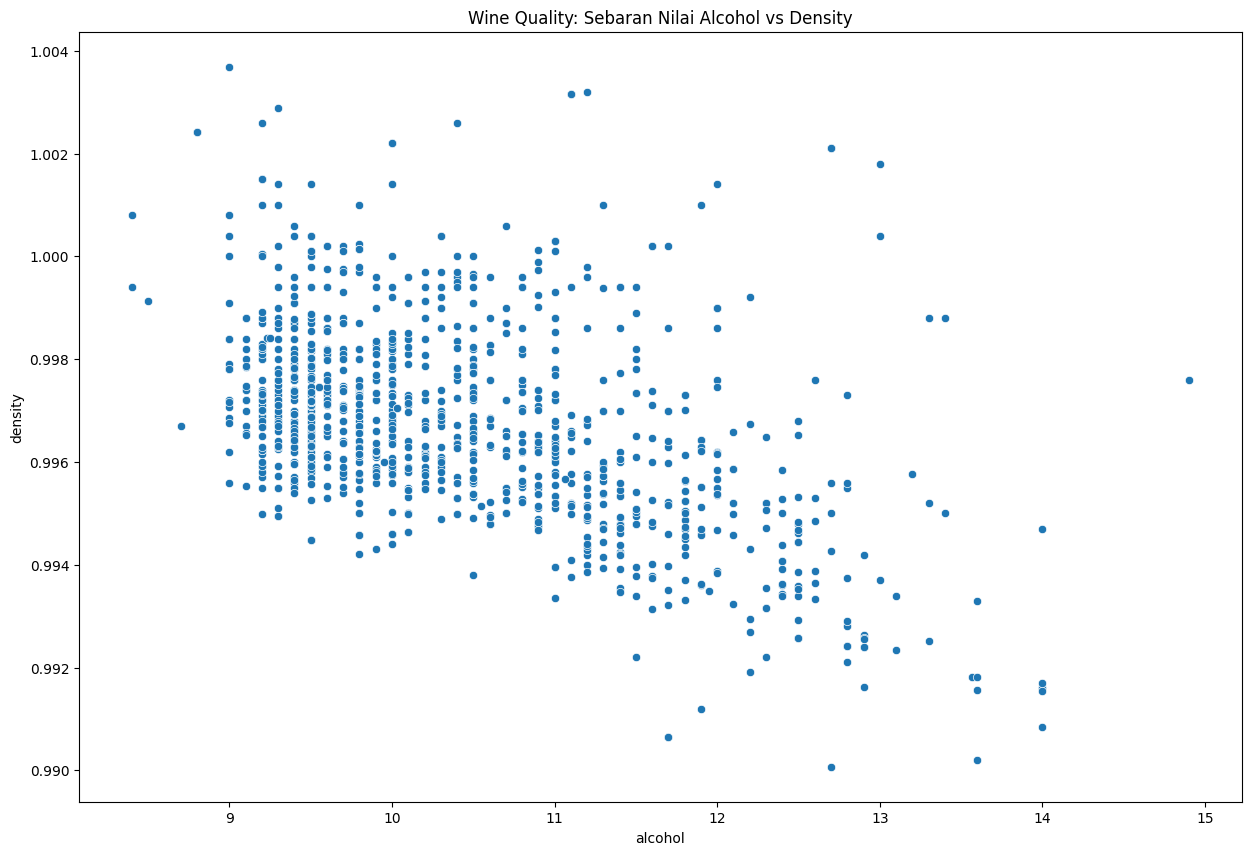

In [14]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='density')
plt.title('Wine Quality: Sebaran Nilai Alcohol vs Density')

In [15]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


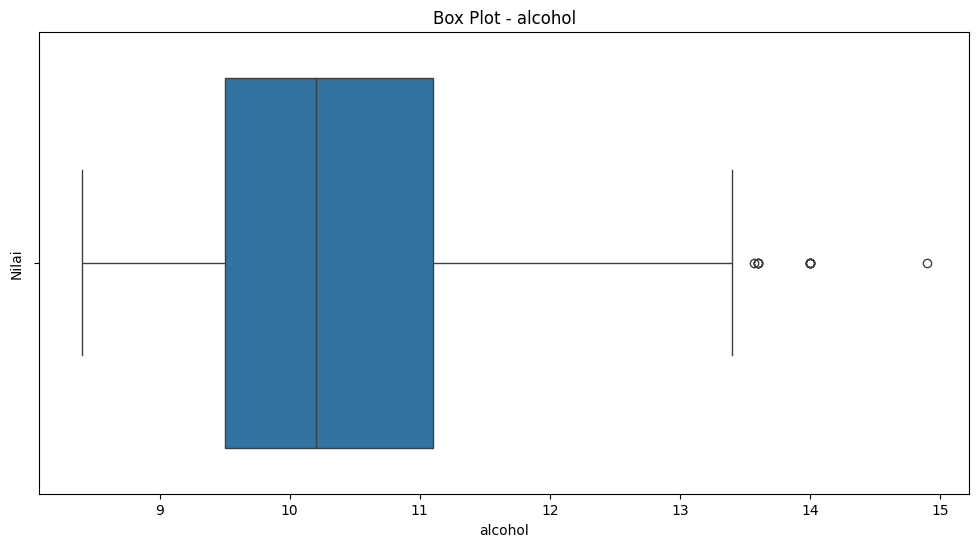

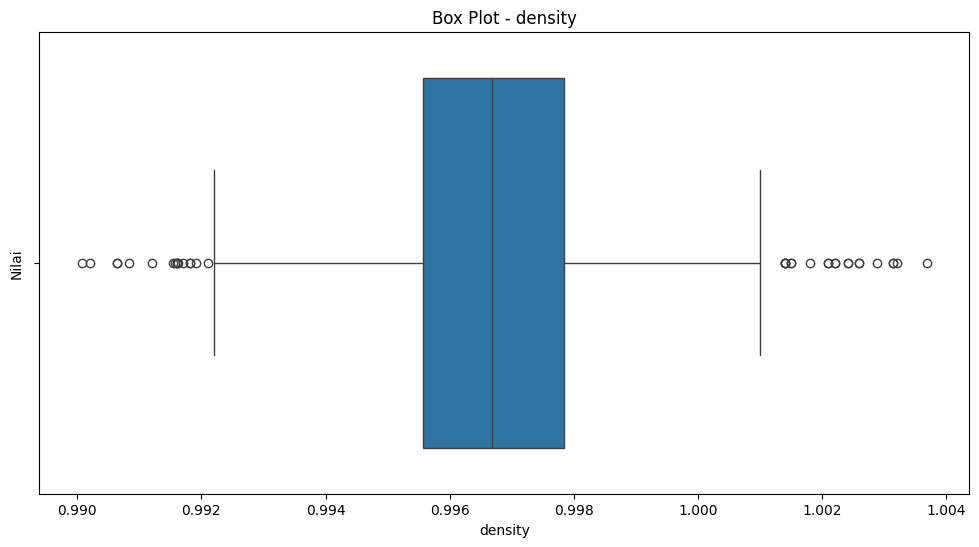

In [16]:
# Looping untuk kolom 'alcohol' dan 'density'
columns = ['alcohol', 'density']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

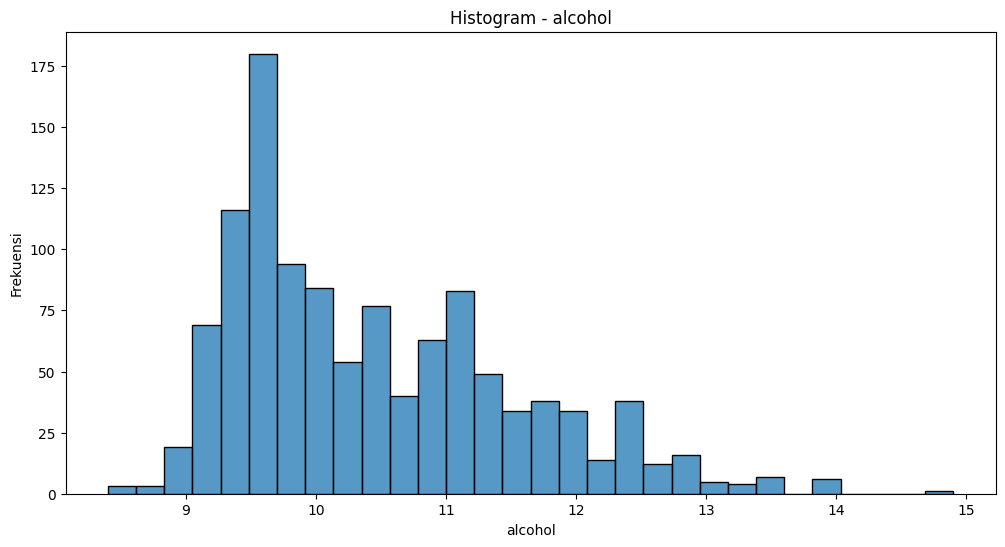

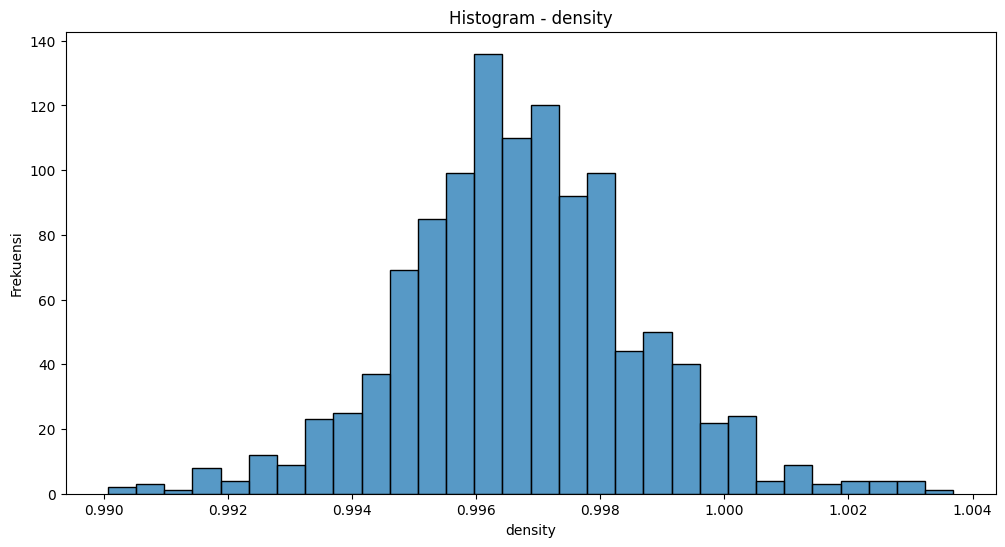

In [17]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional) -> pada dataset wine ini cukup dilihat dulu, karena fitur-fitur sudah berupa nilai kimia yang wajar
3. Feature Scalling
4. Gunakan semua fitur numerik untuk clustering, kecuali quality dan Id

In [18]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


dari hasil running program diatas, tidak ada data yg duplikat

In [19]:
feature_columns = [col for col in df.columns if col not in ['quality', 'Id']]
X = df[feature_columns].values
y = df['quality'].values #anotator label

In [20]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data=X_std, columns=feature_columns)
df_scalling.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03
mean,-3.729883e-16,4.475860e-16,2.486589e-17,1.554118e-16,8.081413e-17,-5.594825e-17,9.946355e-17,5.783805e-14,-8.454402e-16,4.973178e-17,-1.193563e-15
std,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00
min,-2.124483e+00,-2.290883e+00,-1.365027e+00,-1.204252e+00,-1.585988e+00,-1.426458e+00,-1.218108e+00,-3.461348e+00,-3.646432e+00,-1.924024e+00,-1.887834e+00
25%,-6.933192e-01,-7.732388e-01,-9.072439e-01,-4.664214e-01,-3.583880e-01,-8.408632e-01,-7.603412e-01,-6.030539e-01,-6.769982e-01,-6.323694e-01,-8.709366e-01
50%,-2.353469e-01,-6.314838e-02,-9.340780e-02,-2.450722e-01,-1.678983e-01,-2.552689e-01,-2.720568e-01,-2.619819e-02,-6.480857e-03,-2.213884e-01,-2.238203e-01
75%,4.516116e-01,6.051720e-01,7.712930e-01,5.006018e-02,6.492241e-02,5.255235e-01,4.603699e-01,5.792404e-01,5.682483e-01,4.244390e-01,6.081863e-01
max,4.344377e+00,5.840349e+00,3.721449e+00,9.568078e+00,1.109216e+01,5.112679e+00,7.418423e+00,3.616827e+00,4.463634e+00,7.880809e+00,4.121103e+00


In [21]:
X_std

array([[-0.52157961,  0.93933222, -1.36502663, ...,  1.27069495,
        -0.57365783, -0.96338181],
       [-0.29259344,  1.94181282, -1.36502663, ..., -0.70892755,
         0.1308811 , -0.59360107],
       [-0.29259344,  1.27349242, -1.16156762, ..., -0.32577481,
        -0.04525363, -0.59360107],
       ...,
       [-1.20853813,  0.38239855, -0.9581086 , ...,  0.88754221,
        -0.45623467,  0.05351522],
       [-1.38027776,  0.10393172, -0.8563791 , ...,  1.33455374,
         0.60057372,  0.70063152],
       [-1.38027776,  0.6330187 , -0.75464959, ...,  1.65384769,
         0.30701583, -0.22382033]])

In [22]:
df_scalling

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
...,...,...,...,...,...,...,...,...,...,...,...
1138,-1.151292,-0.118842,-0.703785,-0.171289,-0.231395,1.306316,-0.180503,-0.514707,0.695966,0.541862,0.515741
1139,-0.865059,0.493785,-0.958109,-0.466421,-0.400719,1.208717,-0.241539,-0.114545,0.695966,0.952843,-0.870937
1140,-1.208538,0.382399,-0.958109,-0.392638,0.064922,1.599113,-0.058432,-0.951246,0.887542,-0.456235,0.053515
1141,-1.380278,0.103932,-0.856379,-0.245072,-0.527712,2.282306,0.155192,-0.836914,1.334554,0.600574,0.700632


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

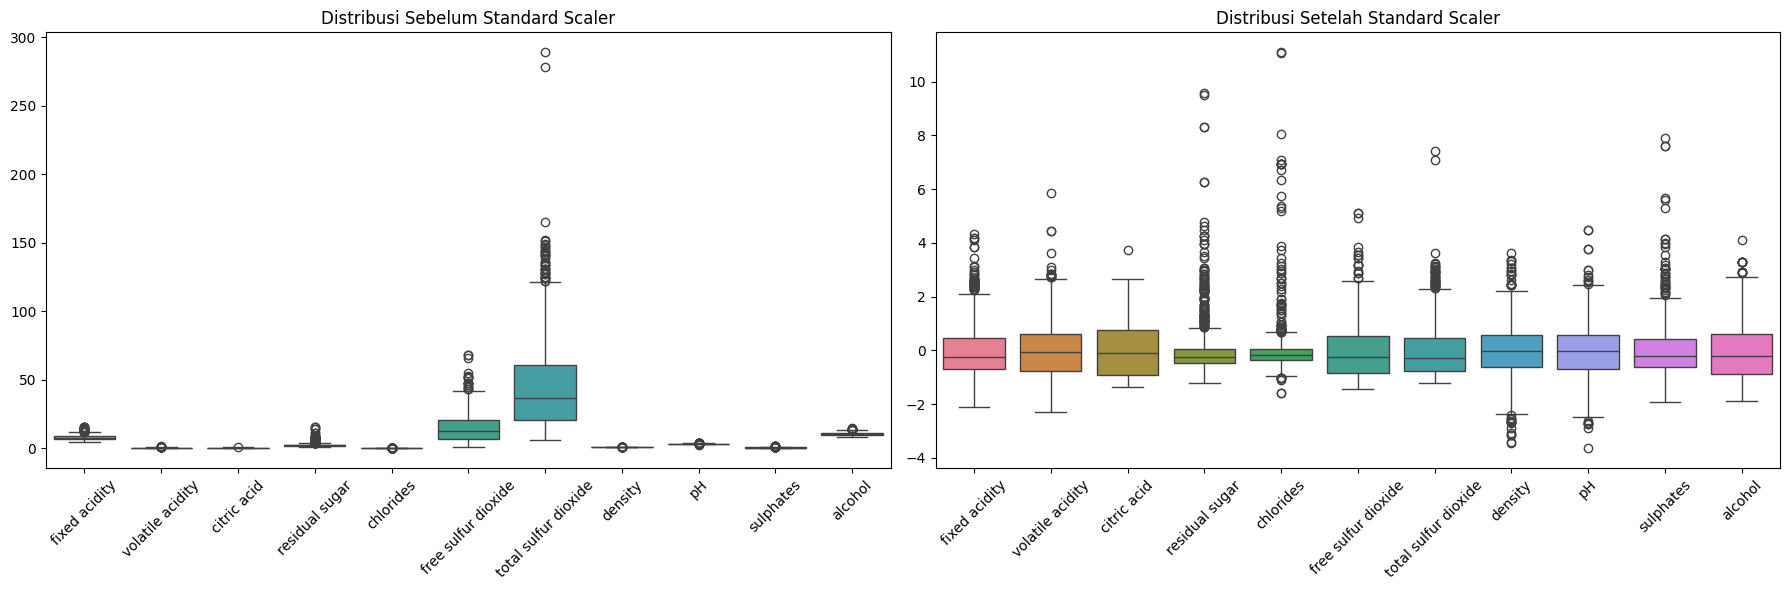

In [23]:
#cek grafik sebelum dan setelah scalling
# kita lihat distribusi dari semua variabel sebelum standar scaller dan setelah standar scaller

from sklearn.preprocessing import StandardScaler
feature_columns = [col for col in df.columns if col not in ['quality', 'Id']]
X = df[feature_columns].values
df_scalling = pd.DataFrame(StandardScaler().fit_transform(X), columns=feature_columns)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18, 6))

# Plot distribusi sebelum Standar Scaler
sns.boxplot(data=df[feature_columns], ax=ax1)
ax1.set_title('Distribusi Sebelum Standard Scaler')
ax1.tick_params(axis='x', rotation=45)

# Plot distribusi setelah Standar Scaler
sns.boxplot(data=df_scalling[feature_columns], ax=ax2)
ax2.set_title('Distribusi Setelah Standard Scaler')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Sebelum Standard Scaler, setiap fitur wine memiliki skala yang sangat berbeda. Contohnya fixed acidity dan alcohol berada pada rentang yang jauh lebih besar dibanding density yang nilainya sangat kecil.
2. Setelah Standard Scaler, seluruh fitur numerik yang dipakai clustering menjadi berada pada skala yang sama dengan mean=0 dan standar deviasi=1.
3. Transformasi ini penting agar K-Means tidak bias ke fitur tertentu yang punya nilai numerik lebih besar, karena K-Means memakai jarak Euclidean.
4. Dengan scaling, semua fitur seperti fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, dan alcohol ikut berkontribusi seimbang dalam proses clustering.


## K-means Clustering Wine Quality
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, dengan membandingkan hasil clustering dengan quality label dari dataset.
1. Metode Elbow
2. Via-Score plot


### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

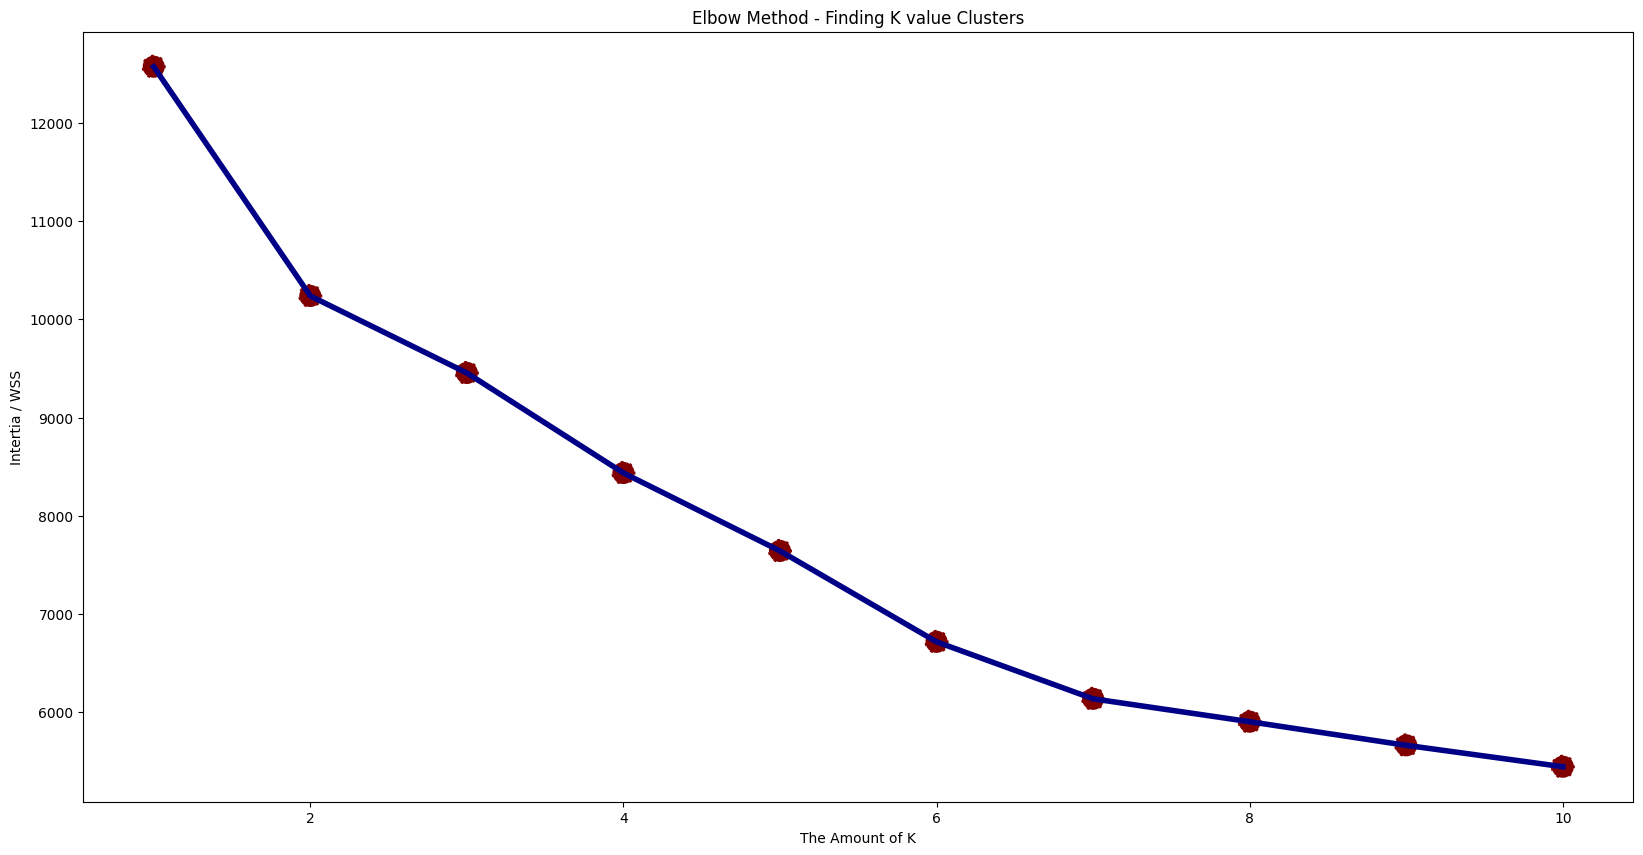

In [24]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [25]:
#Dari hasil diatas elbow nya dipilih pada angka 4,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=4, random_state=0)
kmeans_elbow.fit(df_scalling.values)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [26]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [27]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,3
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,3
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,3
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,2
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,3
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,3
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,1


<Axes: xlabel='alcohol', ylabel='density'>

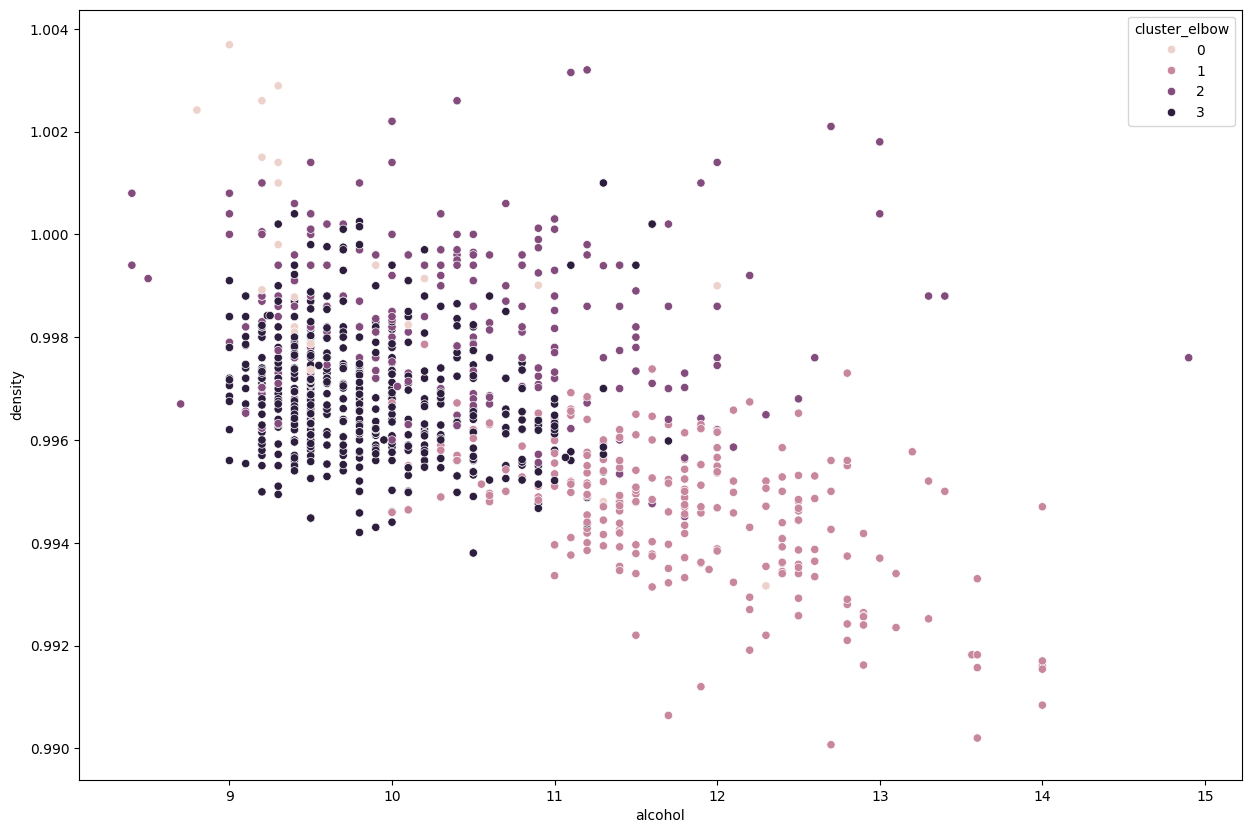

In [28]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='density', hue='cluster_elbow')

### Bandingkan hasil dengan label anotator

<Axes: xlabel='alcohol', ylabel='density'>

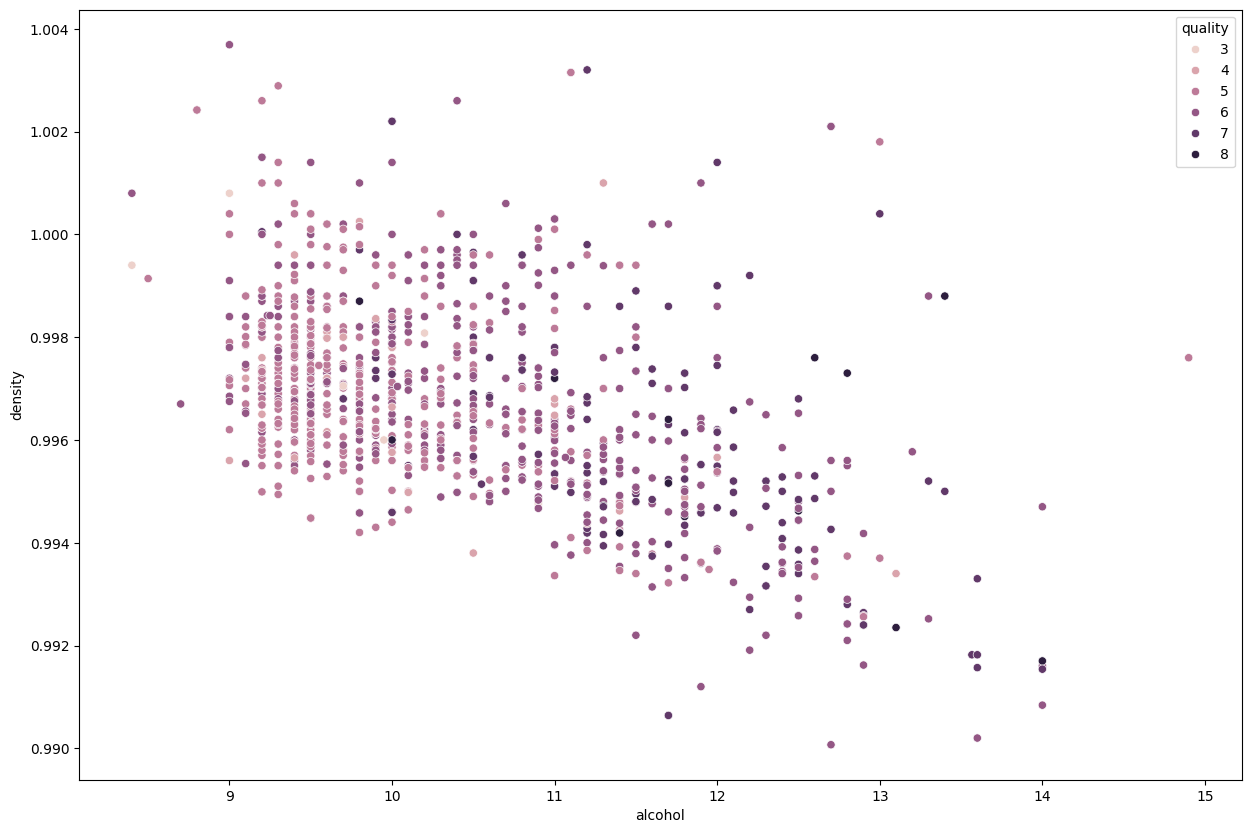

In [29]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='density',hue='quality')

### Hasil Clustering Elbow Method vs Quality Label
Dari hasil elbow method, nilai K = 4 dipilih karena kurva inertia mulai melandai setelah titik tersebut. Artinya, penambahan cluster setelah 4 tidak lagi memberi penurunan error yang signifikan.

Perlu dipahami bahwa hasil ini memang bisa berbeda dari via-score, karena elbow method dan via-score memakai pendekatan evaluasi yang berbeda. Jadi K = 4 pada elbow bukan bertentangan dengan K = 5 pada via-score, tetapi menunjukkan bahwa masing-masing metode menemukan titik optimal yang berbeda menurut kriterianya.

### 2. Via Score Plot

In [30]:
!pip install yellowbrick

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


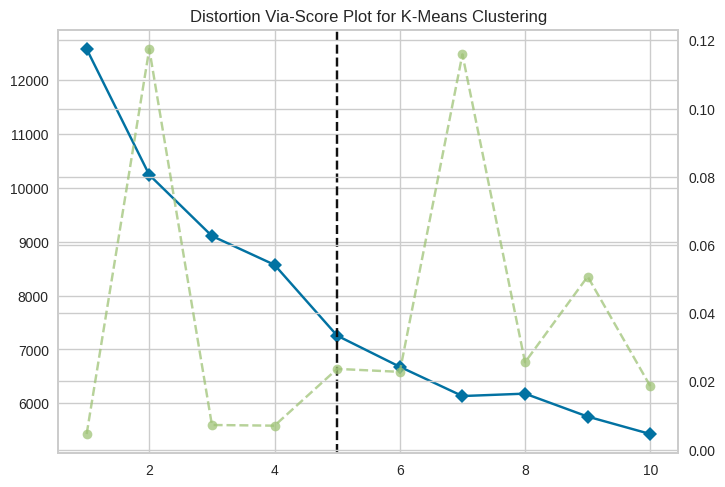

In [37]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [38]:
# Dari hasil diatas K-nya dipilih pada angka 5,
# karena garis putus-putus penanda optimum bertemu di nilai 5 pada sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=5, random_state=0)
kmeans_via.fit(df_scalling.values)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [39]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [34]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,3,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,3,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,3,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,2,2
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,3,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,3,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,1,1


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

<Axes: xlabel='alcohol', ylabel='density'>

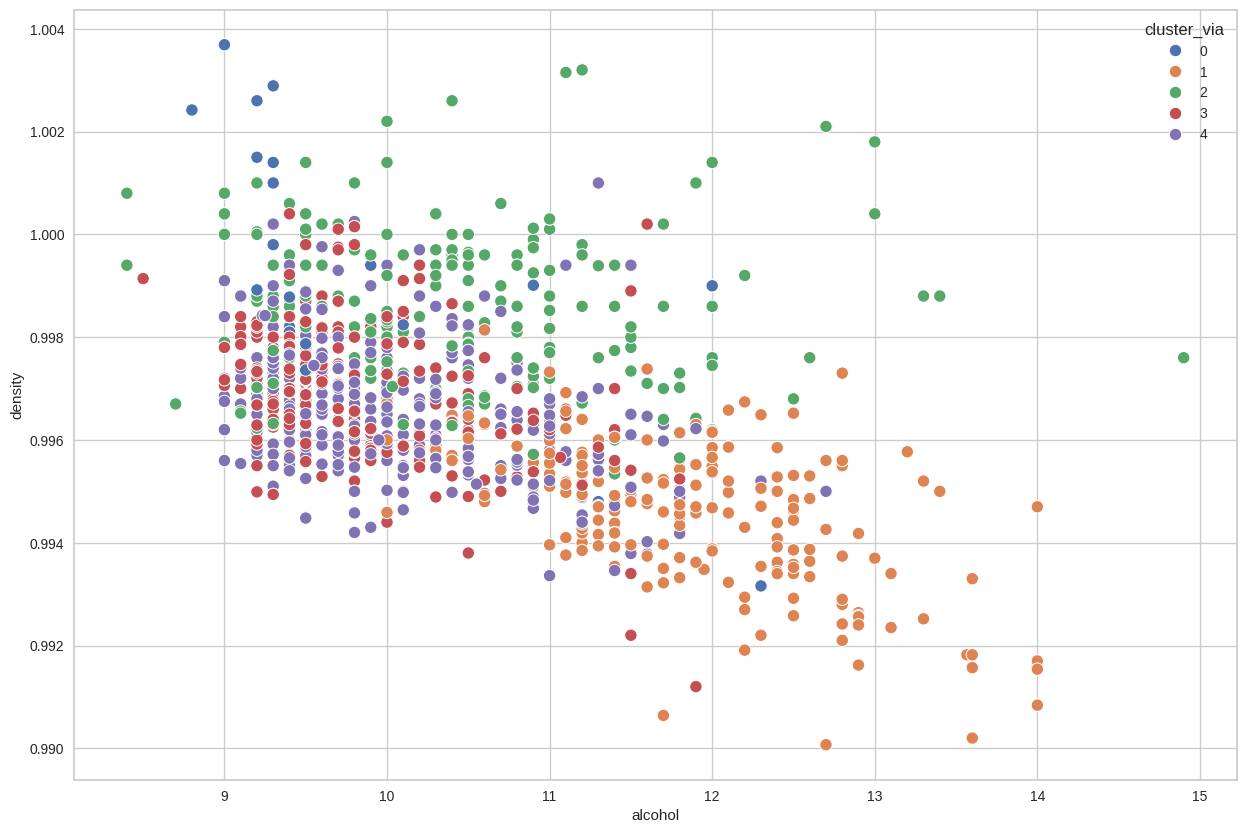

In [40]:
#Lakukan evaluasi setelah dilakukan K-Means
#Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='density', hue='cluster_via', palette='deep', s=80)

### Bandingkan dengan label anotator

<Axes: xlabel='alcohol', ylabel='density'>

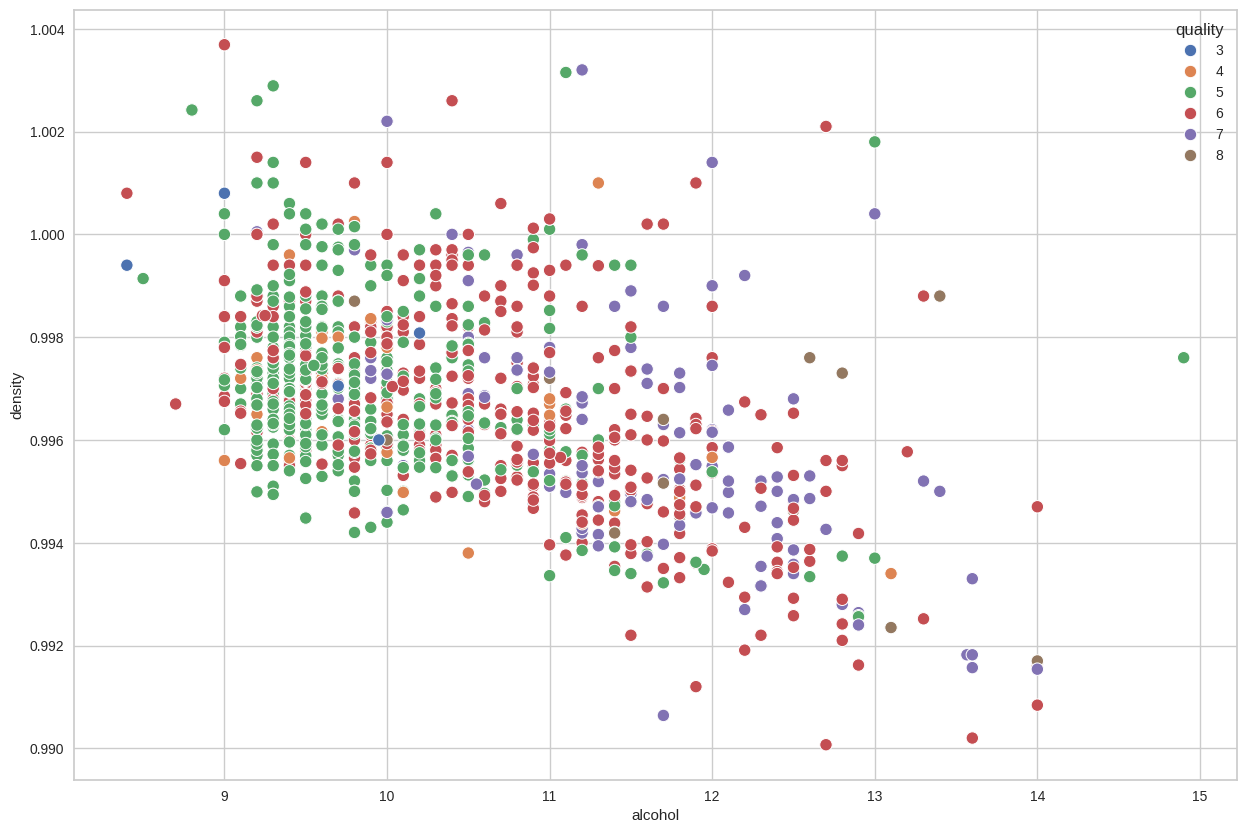

In [36]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='density', hue='quality', palette='deep', s=80)

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. **Perbandingan Metode Elbow vs Via-Score untuk Wine Quality Data**: Elbow method pada notebook ini menunjukkan K = 4, sedangkan via-score menunjukkan K = 5. Perbedaan ini wajar karena kedua metode menilai titik optimal dengan pendekatan yang berbeda. Elbow melihat penurunan inertia, sedangkan via-score mencari titik knee pada kurva distorsi.

2. **Makna Perbedaan K**: K yang berbeda bukan berarti salah satu metode gagal. Justru ini menunjukkan bahwa struktur cluster pada WineQT cukup kompleks ketika semua fitur numerik dipakai, sehingga hasil optimal bisa bergeser tergantung metrik evaluasi.

3. **Kualitas Clustering Berdasarkan Seluruh Fitur**: Clustering sekarang memakai fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, dan alcohol. Dengan semua fitur ini, hasil cluster lebih representatif dibanding hanya memakai dua fitur.

4. **Kesimpulan**: Untuk tugas unsupervised learning, memakai semua fitur numerik yang relevan sudah tepat. Dalam interpretasi, cukup jelaskan bahwa elbow menghasilkan K = 4 dan via-score menghasilkan K = 5, lalu keduanya dibandingkan sebagai dua alternatif hasil clustering.


### Thank you :)